<a href="https://colab.research.google.com/github/patilyogita7/Artificial_Intelligence_Lab_SE_A_45/blob/master/Practical_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

In [5]:
from google.colab import files
uploaded = files.upload()

Saving movies.csv to movies.csv


In [6]:
from google.colab import files
uploaded = files.upload()

Saving ratings.csv to ratings.csv


In [8]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")
movies = movies.rename(columns={'index': 'movieId'})
data = pd.merge(ratings, movies, on="movieId")
data.head()

,userId,movieId,rating,timestamp,budget,genres,homepage,id,keywords,original_language,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,1,1,4.0,964982703,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
1,1,3,4.0,964981247,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
2,1,6,4.0,964982224,260000000,Animation Family,http://disney.go.com/disneypictures/tangled/,38757,hostage magic horse fairy tale musical,en,...,100.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,They're taking adventure to new lengths.,Tangled,7.4,3330,Zachary Levi Mandy Moore Donna Murphy Ron Perl...,"[{'name': 'John Lasseter', 'gender': 2, 'depar...",Byron Howard
3,1,47,5.0,964983815,190000000,Action Adventure Science Fiction,NaN,54138,spacecraft friendship sequel futuristic space,en,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Earth Will Fall,Star Trek Into Darkness,7.4,4418,Chris Pine Zachary Quinto Zoe Saldana Karl Urb...,"[{'name': 'Michael Kaplan', 'gender': 2, 'depa...",J.J. Abrams
4,1,50,5.0,964982931,150000000,Adventure Fantasy Action Romance,http://disney.go.com/disneypictures/princeofpe...,9543,persia sandstorm brother against brother armag...,en,...,116.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Defy the Future,Prince of Persia: The Sands of Time,6.2,2317,Jake Gyllenhaal Gemma Arterton Ben Kingsley Al...,"[{'name': 'Sarah Bradshaw', 'gender': 0, 'depa...",Mike Newell


In [9]:
data['genres'] = data['genres'].astype('category').cat.codes

In [10]:
X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_reg, test_size=0.2, random_state=42)

In [13]:
reg = RandomForestRegressor()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

In [28]:
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)
y_cls = data['rating_class']

In [40]:
y_cls = (data['rating'] >= 3.5).astype(int)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
X, y_cls, test_size=0.2, random_state=42)

In [41]:
clf = RandomForestClassifier()
clf.fit(X_train_cls, y_train_cls)
y_pred_cls = clf.predict(X_test_cls)

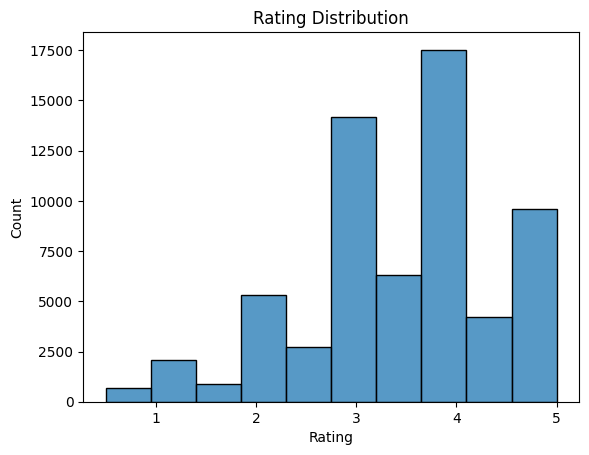

In [35]:
plt.figure()
sns.histplot(data['rating'], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [37]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Regression Evaluation:")
print("MAE :", round(mae, 3))
print("MSE :", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R2  :", round(r2, 3))

Regression Evaluation:
MAE : 0.785
MSE : 1.014
RMSE: 1.007
R2  : 0.087


Accuracy: 0.633215269578906

Classification Report:

              precision    recall  f1-score   support

           0       0.55      0.53      0.54      5133
           1       0.69      0.70      0.70      7572

    accuracy                           0.63     12705
   macro avg       0.62      0.62      0.62     12705
weighted avg       0.63      0.63      0.63     12705



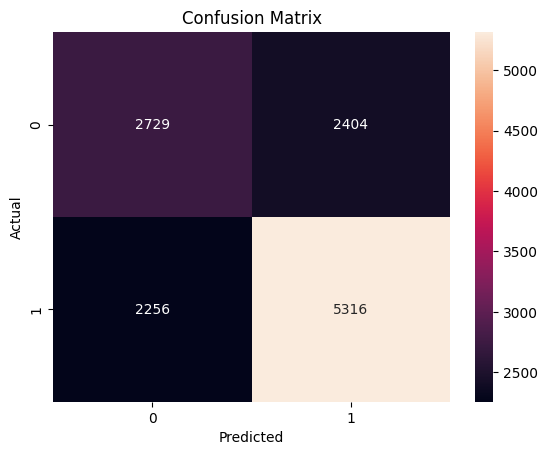

In [43]:
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)

X = data[['userId', 'movieId', 'genres']]
y = data['rating_class']

# Predictions
y_pred_cls = clf.predict(X_test_cls)

# Evaluation
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("\nClassification Report:\n")
print(classification_report(y_test_cls, y_pred_cls))

# Confusion Matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()